In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

sns.set(style="whitegrid")

In [ ]:
# CZĘŚĆ 1
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = y

print(f"Liczba próbek: {df.shape[0]}")
print(f"Liczba cech: {df.shape[1] - 1}")
print(f"Nazwy cech: {feature_names}")
print("\nRozkład klas:")
print(df['class'].value_counts().sort_index())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Liczba próbek: 178
Liczba cech: 13
Nazwy cech: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Rozkład klas:
class
0    59
1    71
2    48
Name: count, dtype: int64


In [ ]:
# CZĘŚĆ 2
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Wyjaśniona wariancja przez każdą składową:\n{explained_variance}")
print(f"Skumulowana wariancja:\n{cumulative_variance}")

n_components_80 = np.argmax(cumulative_variance > 0.80) + 1
print(f"\nLiczba składowych potrzebna do wyjaśnienia >80% wariancji: {n_components_80}")

Wyjaśniona wariancja przez każdą składową:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
Skumulowana wariancja:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Liczba składowych potrzebna do wyjaśnienia >80% wariancji: 5


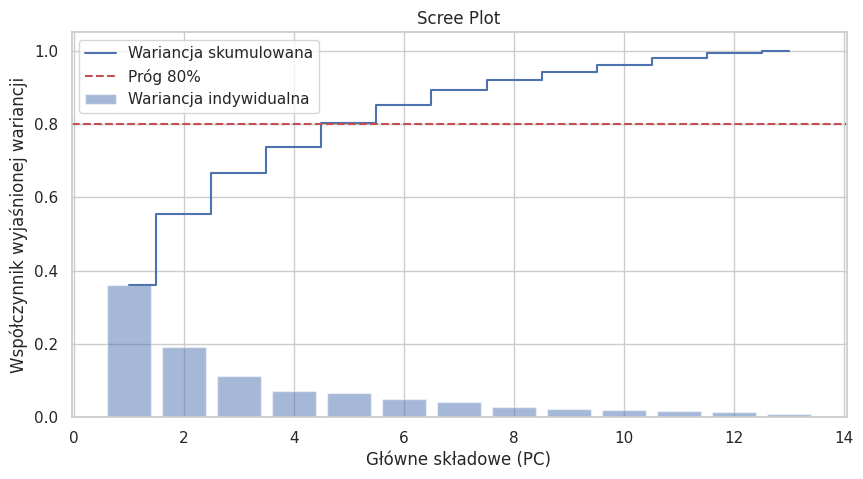

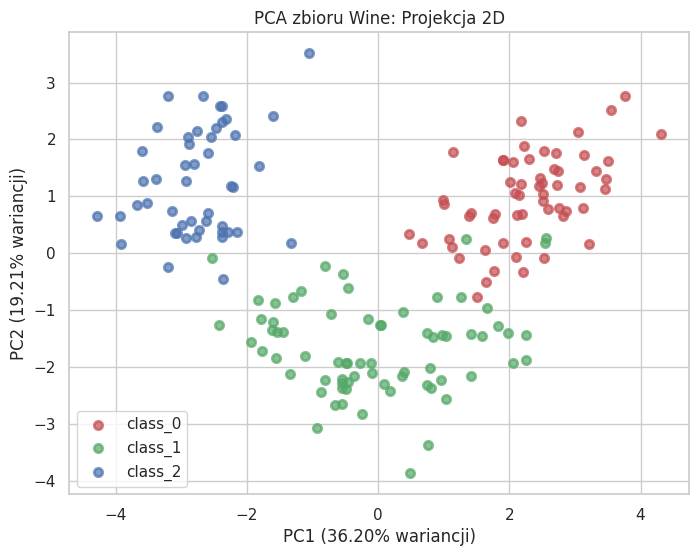

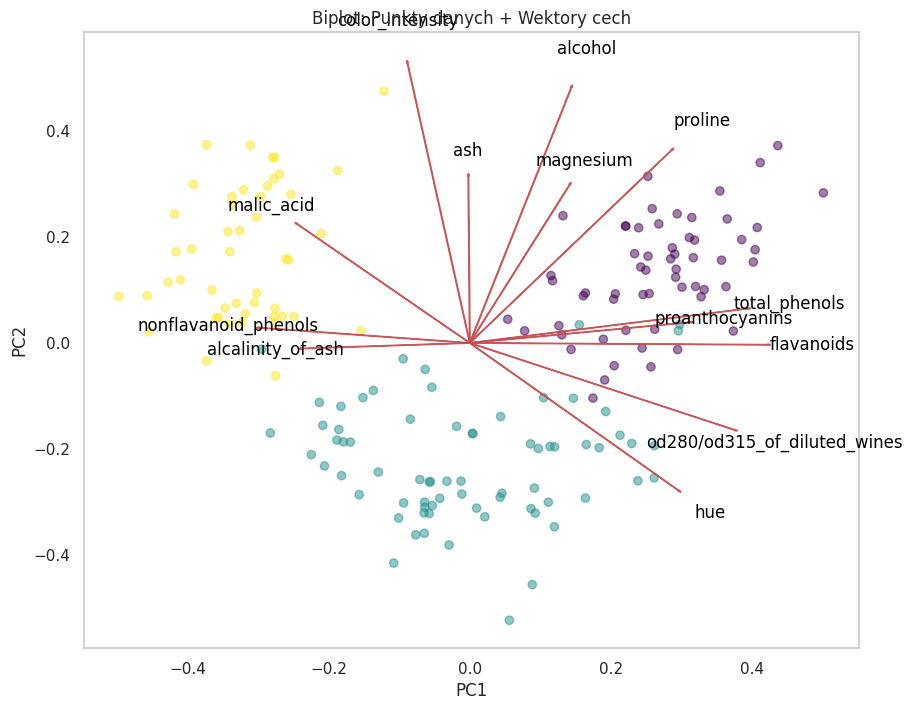

In [ ]:
# CZĘŚĆ 3
plt.figure(figsize=(10, 5))
plt.bar(range(1, 14), explained_variance, alpha=0.5, align='center', label='Wariancja indywidualna')
plt.step(range(1, 14), cumulative_variance, where='mid', label='Wariancja skumulowana')
plt.ylabel('Współczynnik wyjaśnionej wariancji')
plt.xlabel('Główne składowe (PC)')
plt.axhline(y=0.8, color='r', linestyle='--', label='Próg 80%')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.show()

plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for target, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X_pca[y == target, 0], X_pca[y == target, 1],
                color=color, alpha=0.7, lw=2, label=label)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} wariancji)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} wariancji)')
plt.title('PCA zbioru Wine: Projekcja 2D')
plt.show()

def biplot(score, coeff, labels=None, targets=None):
    plt.figure(figsize=(10, 8))
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    scatter = plt.scatter(xs * scalex, ys * scaley, c=targets, cmap='viridis', alpha=0.5)

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='r', alpha=0.9)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color='black', ha='center', va='center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot: Punkty danych + Wektory cech")
    plt.grid()

biplot(X_pca, pca.components_.T, labels=feature_names, targets=y)
plt.show()

In [ ]:
# CZĘŚĆ 4
loadings = pd.DataFrame(pca.components_[0:2, :], columns=feature_names, index=['PC1', 'PC2'])
print("\n--- Ładunki (Loadings) ---")
print(loadings.T.sort_values(by='PC1', ascending=False))


--- Ładunki (Loadings) ---
                                   PC1       PC2
flavanoids                    0.422934 -0.003360
total_phenols                 0.394661  0.065040
od280/od315_of_diluted_wines  0.376167 -0.164496
proanthocyanins               0.313429  0.039302
hue                           0.296715 -0.279235
proline                       0.286752  0.364903
alcohol                       0.144329  0.483652
magnesium                     0.141992  0.299634
ash                          -0.002051  0.316069
color_intensity              -0.088617  0.529996
alcalinity_of_ash            -0.239320 -0.010591
malic_acid                   -0.245188  0.224931
nonflavanoid_phenols         -0.298533  0.028779


1.

Dominujące cechy dodatnie:

flavanoids (0.42)

total_phenols (0.39)

od280/od315_of_diluted_wines (0.38)

Dominujące cechy ujemne:

nonflavanoid_phenols (-0.30)

Pierwsza składowa PC1 jest silnie skorelowana ze zmiennymi opisującymi skład chemiczny i jakość fenolową wina. Cechy takie jak flavanoids i total_phenols są wskaźnikami bogactwa związków chemicznych w winie, które wpływają m.in. na jego smak. Wina o wysokiej wartości na osi PC1 są bogate we flawonoidy i fenole. Można powiedzieć, że PC1 reprezentuje złożoność chemiczną wina.

2.
Dominujące cechy dodatnie:

color_intensity (0.53)

alcohol (0.48)

proline (0.36)

Dominujące cechy ujemne:

hue (-0.28)

Druga składowa PC2 skupia się na wyglądzie i mocy wina. Wysoka wartość color_intensity i alcohol sugeruje wina ciemne, mocne i esencjonalne. Ujemna korelacja z hue (odcień) potwierdza ten związek (ciemniejsze wina mają niższy współczynnik odcienia w kierunku barw jasnych). PC2 można nazwać osią mocy i intensywności koloru.

3.

Biorąc pod uwagę te ładunki, separacja w przestrzeni 2D powinna być bardzo wyraźna:

Klasa 0 (Barolo) zazwyczaj charakteryzuje się wysokim poziomem flawonoidów i alkoholu, więc znajdzie się w "górnym prawym" lub "prawym" obszarze wykresu (wysokie PC1, wysokie PC2).

Klasa 1 (Grignolino) ma zazwyczaj niższy poziom alkoholu i intensywności koloru, więc powinna oddzielić się wzdłuż osi PC2 (niskie wartości PC2).

Klasa 2 (Barbera) ma często niższy poziom flawonoidów (niskie PC1), ale wysoką intensywność koloru (wysokie PC2).

Wniosek: Dzięki temu, że PC1 i PC2 opierają się na zupełnie różnych grupach cech (Chemia vs. Wygląd/Moc), rzutowanie na te dwie osie pozwala skutecznie rozróżnić wszystkie trzy odmiany winogron na wykresie.